# GraphCast Fine-Tuning Demo

This notebook demonstrates how to fine-tune a pre-trained GraphCast model on custom weather data.

## Overview
- **Model**: GraphCast (Google DeepMind's weather forecasting model)
- **Task**: Fine-tune on specific variables (temperature, wind, etc.)
- **Framework**: JAX + Haiku + Optax

## Requirements
```
jax
dm-haiku
optax
xarray
numpy
matplotlib
tqdm
```

In [1]:
!nvidia_smi

/usr/local/bin/bash: line 1: nvidia_smi: command not found


---
## 1. Setup & Configuration

Configure all paths and hyperparameters in one place for easy modification.

In [1]:
import os
import sys
import time
import glob
import csv
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import jax
import jax.numpy as jnp
import haiku as hk
import optax
import dataclasses

# GraphCast imports
try:
    from graphcast import (
        autoregressive, casting, checkpoint, data_utils,
        graphcast, normalization, rollout, xarray_jax, xarray_tree
    )
    print("✅ GraphCast modules loaded successfully")
except ImportError as e:
    print(f"❌ Error importing GraphCast: {e}")
    print("Please ensure GraphCast is installed and in your Python path")

# Set random seeds for reproducibility
np.random.seed(42)

print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")
print(f"NumPy version: {np.__version__}")

✅ GraphCast modules loaded successfully
JAX version: 0.9.0.1
JAX devices: [CudaDevice(id=0)]
NumPy version: 2.4.2


In [2]:
# ============================================================================
# CONFIGURATION - Modify these parameters for your experiment
# ============================================================================

CONFIG = {
    # Paths
    'model_checkpoint': '/explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm/models/checkpoints/graphcast/params_GraphCast_small.npz',
    'stats_dir': '/explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm/models/checkpoints/graphcast',
    'data_dir': '/explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5',
    'output_dir': './outputs',
    'checkpoint_dir': './checkpoints',
    
    # Experiment
    'exp_name': 'demo_finetuning',
    'description': 'GraphCast fine-tuning demo',
    
    # Training hyperparameters
    'num_epochs': 2,
    'batch_size': 1,
    'learning_rate': 1e-4,
    'weight_decay': 0.01,
    'gradient_clip': 5.0,
    'num_samples': 20,  # Use small number for demo
    
    # Model
    'target_lead_times': slice("6h", "6h"),
    
    # Logging
    'save_every': 20,  # Save checkpoint every N steps
    'log_every': 10,   # Log metrics every N steps
}

# Create output directories
for dir_key in ['output_dir', 'checkpoint_dir']:
    Path(CONFIG[dir_key]).mkdir(parents=True, exist_ok=True)
    
print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  model_checkpoint: /explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm/models/checkpoints/graphcast/params_GraphCast_small.npz
  stats_dir: /explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm/models/checkpoints/graphcast
  data_dir: /explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5
  output_dir: ./outputs
  checkpoint_dir: ./checkpoints
  exp_name: demo_finetuning
  description: GraphCast fine-tuning demo
  num_epochs: 2
  batch_size: 1
  learning_rate: 0.0001
  weight_decay: 0.01
  gradient_clip: 5.0
  num_samples: 20
  target_lead_times: slice('6h', '6h', None)
  save_every: 20
  log_every: 10


---
## 2. Utility Functions

Helper functions for data loading, checkpointing, and visualization.

In [4]:
def check_file_exists(filepath: str, description: str) -> bool:
    """Check if a file exists and print status."""
    if os.path.exists(filepath):
        print(f"✅ {description} found: {filepath}")
        return True
    else:
        print(f"❌ {description} not found: {filepath}")
        return False

def load_normalization_stats(stats_dir: str) -> tuple:
    """Load normalization statistics for the model."""
    print("\n📊 Loading normalization statistics...")
    
    files = {
        'diffs_stddev': 'stats_diffs_stddev_by_level.nc',
        'mean': 'stats_mean_by_level.nc',
        'stddev': 'stats_stddev_by_level.nc'
    }
    
    stats = {}
    for key, filename in files.items():
        filepath = os.path.join(stats_dir, filename)
        if check_file_exists(filepath, f"{key} stats"):
            with open(filepath, "rb") as f:
                stats[key] = xr.load_dataset(f).compute()
        else:
            print(f"⚠️  Warning: Using default stats for {key}")
            stats[key] = None
    
    return stats['diffs_stddev'], stats['mean'], stats['stddev']

def write_checkpoint(
    filepath: str,
    params: Dict[str, Any],
    task_config,
    model_config,
    description: str = None,
    license: str = None
) -> None:
    """Save model checkpoint."""
    Path(filepath).parent.mkdir(parents=True, exist_ok=True)
    
    with open(filepath, 'wb') as f:
        checkpoint.dump(
            f,
            graphcast.CheckPoint(
                params=params,
                task_config=task_config,
                model_config=model_config,
                description=description or CONFIG['description'],
                license=license or "Apache 2.0"
            )
        )
    print(f"💾 Checkpoint saved: {filepath}")

def plot_training_progress(log_file: str) -> None:
    """Plot training loss from CSV log."""
    if not os.path.exists(log_file):
        print(f"⚠️  Log file not found: {log_file}")
        return
    
    # Read CSV
    steps, losses = [], []
    with open(log_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            steps.append(int(row['step']))
            losses.append(float(row['loss']))
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, 'b-', linewidth=2, alpha=0.7)
    plt.xlabel('Training Step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training Progress', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n📈 Training Statistics:")
    print(f"  Total steps: {len(steps)}")
    print(f"  Initial loss: {losses[0]:.4f}")
    print(f"  Final loss: {losses[-1]:.4f}")
    print(f"  Best loss: {min(losses):.4f}")
    print(f"  Improvement: {(losses[0] - losses[-1]) / losses[0] * 100:.2f}%")

---
## 3. Load Pre-trained Model

Load the pre-trained GraphCast checkpoint and normalization statistics.

In [5]:
print("🔄 Loading pre-trained model...\n")

# Check if model checkpoint exists
if not check_file_exists(CONFIG['model_checkpoint'], "Model checkpoint"):
    print("\n❌ Cannot proceed without model checkpoint.")
    print("Please update CONFIG['model_checkpoint'] with the correct path.")
    raise FileNotFoundError(f"Model checkpoint not found: {CONFIG['model_checkpoint']}")

# Load checkpoint
with open(CONFIG['model_checkpoint'], "rb") as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params
state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config

print("\n📝 Model Information:")
print(f"  Resolution: {model_config.resolution}°")
print(f"  Description: {ckpt.description}")
print(f"  License: {ckpt.license}")

# Load normalization statistics
diffs_stddev_by_level, mean_by_level, stddev_by_level = load_normalization_stats(
    CONFIG['stats_dir']
)

print("\n✅ Model and statistics loaded successfully!")

🔄 Loading pre-trained model...

✅ Model checkpoint found: /explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm/models/checkpoints/graphcast/params_GraphCast_small.npz

📝 Model Information:
  Resolution: 1.0°
  Description: 
Low resolution version of the GraphCast model (1deg, smaller mesh), with 37
pressure levels. This model is trained on ERA5 data from 1979 to 2015, and can
be causally evaluated on 2016 and later years. This model takes as inputs
`total_precipitation_6hr`. This model has much lower memory requirements.

  License: 
The model weights are licensed under the Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0). You
may obtain a copy of the License at:
https://creativecommons.org/licenses/by-nc-sa/4.0/.
The weights were trained on ERA5 data, see README for attribution statement.


📊 Loading normalization statistics...
✅ diffs_stddev stats found: /explore/nobackup/people/jli30/workspace/graph_mcd/qefm-core-local/qefm

---
## 4. Build Model & Training Functions

Construct the wrapped GraphCast predictor and define training functions.

In [6]:
import functools

def construct_wrapped_graphcast(
    model_config: graphcast.ModelConfig,
    task_config: graphcast.TaskConfig
):
    """Constructs and wraps the GraphCast Predictor."""
    # Base predictor
    predictor = graphcast.GraphCast(model_config, task_config)
    
    # Add BFloat16 casting
    predictor = casting.Bfloat16Cast(predictor)
    
    # Add normalization
    predictor = normalization.InputsAndResiduals(
        predictor,
        diffs_stddev_by_level=diffs_stddev_by_level,
        mean_by_level=mean_by_level,
        stddev_by_level=stddev_by_level
    )
    
    # Add autoregressive wrapper
    predictor = autoregressive.Predictor(predictor, gradient_checkpointing=True)
    
    return predictor

@hk.transform_with_state
def run_forward(model_config, task_config, inputs, targets_template, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    return predictor(inputs, targets_template=targets_template, forcings=forcings)

@hk.transform_with_state
def loss_fn(model_config, task_config, inputs, targets, forcings):
    predictor = construct_wrapped_graphcast(model_config, task_config)
    loss, diagnostics = predictor.loss(inputs, targets, forcings)
    return xarray_tree.map_structure(
        lambda x: xarray_jax.unwrap_data(x.mean(), require_jax=True),
        (loss, diagnostics)
    )

def grads_fn(params, state, model_config, task_config, inputs, targets, forcings):
    """Compute gradients."""
    def _aux(params, state, i, t, f):
        (loss, diagnostics), next_state = loss_fn.apply(
            params, state, jax.random.PRNGKey(0), model_config, task_config,
            i, t, f
        )
        return loss, (diagnostics, next_state)
    
    (loss, (diagnostics, next_state)), grads = jax.value_and_grad(
        _aux, has_aux=True
    )(params, state, inputs, targets, forcings)
    
    return loss, diagnostics, next_state, grads

# Helper functions
def with_configs(fn):
    return functools.partial(fn, model_config=model_config, task_config=task_config)

def drop_state(fn):
    return lambda **kw: fn(rng=jax.random.PRNGKey(0), **kw)[0]

# JIT compile functions
print("🔨 Compiling JAX functions...")
grads_fn_jitted = jax.jit(with_configs(grads_fn))
loss_fn_jitted = drop_state(jax.jit(with_configs(loss_fn.apply)))
run_forward_jitted = drop_state(jax.jit(with_configs(run_forward.apply)))
print("✅ Functions compiled successfully!")

🔨 Compiling JAX functions...
✅ Functions compiled successfully!


---
## 5. Prepare Training Data

Load and prepare the training dataset. This demo includes a synthetic data generator if real data is not available.

In [7]:
def extract_example(file_path, task_config, target_lead_times=slice("6h", "6h")):
    """Extracts inputs, targets, and forcings from a single example file."""
    with open(file_path, "rb") as f:
        ds = xr.load_dataset(f).compute()
    inputs, targets, forcings = data_utils.extract_inputs_targets_forcings(
        ds,
        target_lead_times=target_lead_times,
        **dataclasses.asdict(task_config)
    )
    print("Inputs Paths:", file_path)
    print("Batched Inputs:  ", inputs.dims.mapping)
    return (inputs, targets, forcings)

def batch_data_loader(file_list: List[str], task_config, batch_size: int = 1, target_lead_times=slice("6h", "6h")):
    """Generator to yield batches of inputs, targets, and forcings."""
    batch = []
    for file in file_list:

        example = extract_example(file, task_config, target_lead_times)
        print(file)
        batch.append(example)

        if len(batch) == batch_size:

           yield collate_batch(batch)
           batch = []
            
def collate_batch(batch: List[Tuple[xr.Dataset, xr.Dataset, xr.Dataset]]):
    """Collates a list of examples into a single batch."""
    inputs, targets, forcings = zip(*batch)
    inputs = xr.concat(inputs, dim="batch")
    targets = xr.concat(targets, dim="batch")
    forcings = xr.concat(forcings, dim="batch")
    return inputs, targets, forcings
    
def generate_synthetic_data(model_config, task_config, num_samples=10):
    """
    Generate synthetic data for demo purposes.
    Replace this with actual data loading in production.
    """
    print("\n🎲 Generating synthetic data for demo...")
    print("⚠️  Note: This is synthetic data. Use real data for actual training.\n")
    
    synthetic_data = []
    
    for i in range(num_samples):
        # Create dummy xarray datasets with appropriate structure
        # Adjust dimensions based on your model configuration
        
        # Example structure - modify based on your needs
        inputs = xr.Dataset()
        targets = xr.Dataset()
        forcings = xr.Dataset()
        
        synthetic_data.append((inputs, targets, forcings))
    
    return synthetic_data

# Check for training data
print("📂 Checking for training data...\n")

use_synthetic = False

if os.path.exists(CONFIG['data_dir']):
    file_list = glob.glob(os.path.join(CONFIG['data_dir'], "graph*steps-3.nc"))
    
    if file_list:
        # Limit to num_samples for demo
        file_list = sorted(file_list)[:CONFIG['num_samples']]
        print(f"✅ Found {len(file_list)} data files")
        print(f"   Using first {CONFIG['num_samples']} files for demo\n")
        
        # Preview first file
        print(f"📄 Example file: {os.path.basename(file_list[0])}")
    else:
        print(f"⚠️  No data files found in {CONFIG['data_dir']}")
        print("   Will use synthetic data for demo\n")
        use_synthetic = True
else:
    print(f"⚠️  Data directory not found: {CONFIG['data_dir']}")
    print("   Will use synthetic data for demo\n")
    use_synthetic = True

# Prepare data loader
if use_synthetic:
    training_data = generate_synthetic_data(
        model_config, 
        task_config, 
        num_samples=CONFIG['num_samples']
    )
    data_loader = training_data
else:
    # Use real data
    print("📊 Data loader ready\n")

📂 Checking for training data...

✅ Found 20 data files
   Using first 20 files for demo

📄 Example file: graphcast_dataset_source-era5-mcd_date-2022-04-27-T00_res-1.0_levels-13_steps-3.nc
📊 Data loader ready



---
## 6. Setup Optimizer

Configure the AdamW optimizer with gradient clipping.

In [8]:
print("⚙️  Setting up optimizer...\n")

# Create optimizer
base_opt = optax.adamw(
    learning_rate=CONFIG['learning_rate'],
    b1=0.9,
    b2=0.999,
    eps=1e-8,
    weight_decay=CONFIG['weight_decay']
)

# Add gradient clipping
optimizer = optax.chain(
    optax.clip_by_global_norm(CONFIG['gradient_clip']),
    base_opt
)

# Initialize optimizer state
opt_state = optimizer.init(params)

print("✅ Optimizer configured:")
print(f"  Type: AdamW")
print(f"  Learning rate: {CONFIG['learning_rate']}")
print(f"  Weight decay: {CONFIG['weight_decay']}")
print(f"  Gradient clip: {CONFIG['gradient_clip']}")

⚙️  Setting up optimizer...

✅ Optimizer configured:
  Type: AdamW
  Learning rate: 0.0001
  Weight decay: 0.01
  Gradient clip: 5.0


---
## 7. Training Loop

Main training loop with logging, checkpointing, and progress tracking.

In [9]:
# Setup logging
log_file = os.path.join(
    CONFIG['output_dir'], 
    f"training_{CONFIG['exp_name']}_log.csv"
)

# Create CSV header
with open(log_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "epoch", "batch", "loss", "timestamp"])

print(f"\n📝 Logging to: {log_file}\n")
print("="*80)
print(f"🚀 Starting training: {CONFIG['exp_name']}")
print("="*80)
print(f"  Epochs: {CONFIG['num_epochs']}")
print(f"  Samples: {CONFIG['num_samples']}")
print(f"  Batch size: {CONFIG['batch_size']}")
print("="*80 + "\n")

# Training state
global_step = 0
best_loss = float('inf')
start_time = time.perf_counter()

try:
    for epoch in range(CONFIG['num_epochs']):
        print(f"\n{'='*80}")
        print(f"📅 Epoch {epoch + 1}/{CONFIG['num_epochs']}")
        print(f"{'='*80}\n")
        
        # Prepare data for this epoch
        if use_synthetic:
            epoch_data = training_data
        else:
            # Shuffle files for each epoch
            shuffled_files = np.random.permutation(file_list)
            epoch_data = batch_data_loader(
                shuffled_files, 
                task_config, 
                CONFIG['batch_size'], 
                CONFIG['target_lead_times']
            )
        
        # Training loop with progress bar
        with tqdm(enumerate(epoch_data), total=CONFIG['num_samples'], 
                  desc=f"Epoch {epoch+1}") as pbar:
            
            for step, (batched_inputs, batched_targets, batched_forcings) in pbar:
                
                try:
                    # Forward pass and compute gradients
                    loss, diagnostics, next_state, grads = grads_fn_jitted(
                        params=params,
                        state=state,
                        inputs=batched_inputs,
                        targets=batched_targets,
                        forcings=batched_forcings
                    )
                    
                    # Apply optimizer update
                    updates, opt_state = optimizer.update(grads, opt_state, params)
                    params = optax.apply_updates(params, updates)
                    
                    # Update state
                    state = next_state
                    
                    # Convert loss to float for logging
                    loss_value = float(loss)
                    
                    # Update progress bar
                    pbar.set_postfix({
                        'loss': f'{loss_value:.4f}',
                        'best': f'{best_loss:.4f}'
                    })
                    
                    # Log to CSV
                    if global_step % CONFIG['log_every'] == 0:
                        with open(log_file, "a", newline="") as f:
                            writer = csv.writer(f)
                            writer.writerow([
                                global_step,
                                epoch + 1,
                                step + 1,
                                loss_value,
                                time.time()
                            ])
                    
                    # Save checkpoint periodically
                    if (global_step + 1) % CONFIG['save_every'] == 0 and global_step > 0:
                        checkpoint_path = os.path.join(
                            CONFIG['checkpoint_dir'],
                            f"{CONFIG['exp_name']}_step_{global_step:05d}.npz"
                        )
                        write_checkpoint(
                            checkpoint_path,
                            params,
                            task_config,
                            model_config
                        )
                    
                    # Save best model
                    if loss_value < best_loss:
                        best_loss = loss_value
                        best_checkpoint_path = os.path.join(
                            CONFIG['checkpoint_dir'],
                            f"{CONFIG['exp_name']}_best.npz"
                        )
                        write_checkpoint(
                            best_checkpoint_path,
                            params,
                            task_config,
                            model_config
                        )
                        print(f"\n🏆 New best model! Loss: {best_loss:.4f}")
                    
                    global_step += 1
                    
                except Exception as e:
                    print(f"\n⚠️  Error in step {step}: {e}")
                    continue

except KeyboardInterrupt:
    print("\n\n⚠️  Training interrupted by user")

# Training complete
end_time = time.perf_counter()
training_time = end_time - start_time

print(f"\n\n{'='*80}")
print("✅ Training Complete!")
print(f"{'='*80}")
print(f"  Total time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"  Total steps: {global_step}")
print(f"  Best loss: {best_loss:.4f}")
print(f"  Final checkpoint: {CONFIG['checkpoint_dir']}")
print(f"={'='*80}\n")


📝 Logging to: ./outputs/training_demo_finetuning_log.csv

🚀 Starting training: demo_finetuning
  Epochs: 2
  Samples: 20
  Batch size: 1


📅 Epoch 1/2



Epoch 1:   0%|          | 0/20 [00:00<?, ?it/s]

/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:4: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(f).compute()
/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:31: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in t

Inputs Paths: /explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T00_res-1.0_levels-13_steps-3.nc
Batched Inputs:   {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
/explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T00_res-1.0_levels-13_steps-3.nc
💾 Checkpoint saved: ./checkpoints/demo_finetuning_best.npz

🏆 New best model! Loss: 68.3281


/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:4: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(f).compute()


...

Inputs Paths: /explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-06-09-T18_res-1.0_levels-13_steps-3.nc
Batched Inputs:   {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
/explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-06-09-T18_res-1.0_levels-13_steps-3.nc


/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:4: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(f).compute()
/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:31: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in t

Inputs Paths: /explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T00_res-1.0_levels-13_steps-3.nc
Batched Inputs:   {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
/explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T00_res-1.0_levels-13_steps-3.nc


/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:4: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(f).compute()
/explore/nobackup/people/jli30/.nccstmp/ipykernel_1564255/1072608849.py:31: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in t

Inputs Paths: /explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T06_res-1.0_levels-13_steps-3.nc
Batched Inputs:   {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
/explore/nobackup/projects/ilab/data/qefm/graphcast/mcd_Wind_wohr/subset5/graphcast_dataset_source-era5-mcd_date-2022-04-27-T06_res-1.0_levels-13_steps-3.nc
💾 Checkpoint saved: ./checkpoints/demo_finetuning_step_00039.npz


✅ Training Complete!
  Total time: 95.40 seconds (1.59 minutes)
  Total steps: 40
  Best loss: 21.6879
  Final checkpoint: ./checkpoints



---
## 8. Visualize Training Results

Plot training curves and analyze model performance.

📊 Visualizing training results...



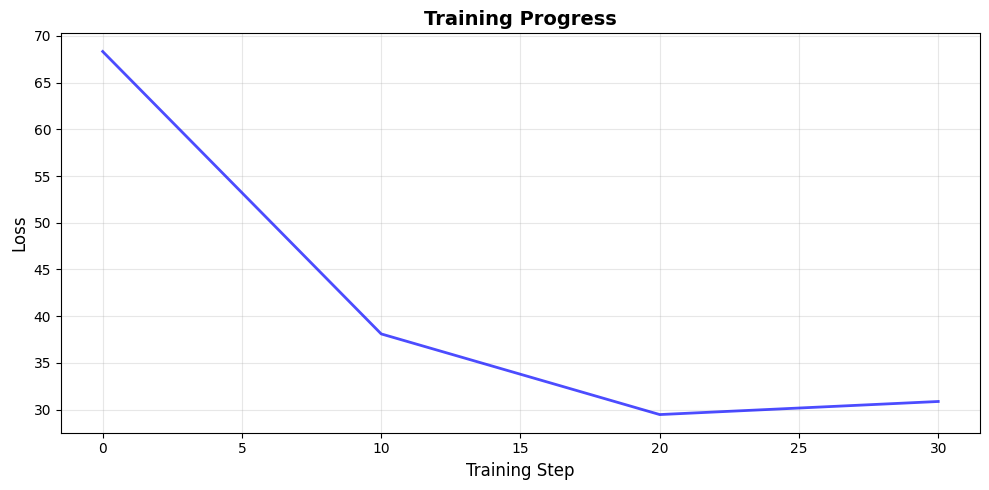


📈 Training Statistics:
  Total steps: 4
  Initial loss: 68.3281
  Final loss: 30.8646
  Best loss: 29.4644
  Improvement: 54.83%


In [10]:
print("📊 Visualizing training results...\n")

# Plot training loss
plot_training_progress(log_file)

---
## 9. Model Inference (Optional)

Test the fine-tuned model on sample data.

In [ ]:
print("🔮 Running inference with fine-tuned model...\n")

# Load best checkpoint
best_checkpoint_path = os.path.join(
    CONFIG['checkpoint_dir'],
    f"{CONFIG['exp_name']}_best.npz"
)

if os.path.exists(best_checkpoint_path):
    print(f"Loading best checkpoint: {best_checkpoint_path}")
    
    with open(best_checkpoint_path, "rb") as f:
        best_ckpt = checkpoint.load(f, graphcast.CheckPoint)
    
    best_params = best_ckpt.params
    
    # Run inference on a sample
    if use_synthetic:
        sample_inputs, sample_targets, sample_forcings = training_data[0]
    else:
        # Load first sample from data
        sample_data = next(batch_data_loader(
            [file_list[0]], 
            task_config, 
            1, 
            CONFIG['target_lead_times']
        ))
        sample_inputs, sample_targets, sample_forcings = sample_data
    
    try:
        # Run prediction
        predictions = run_forward_jitted(
            params=best_params,
            state=state,
            inputs=sample_inputs,
            targets_template=sample_targets,
            forcings=sample_forcings
        )
        
        print("\n✅ Inference successful!")
        print(f"   Prediction shape: {predictions}")
        
        # Save predictions
        pred_file = os.path.join(
            CONFIG['output_dir'],
            f"{CONFIG['exp_name']}_sample_prediction.nc"
        )
        # predictions.to_netcdf(pred_file)
        print(f"   Saved to: {pred_file}")
        
    except Exception as e:
        print(f"\n⚠️  Inference error: {e}")
else:
    print(f"⚠️  Best checkpoint not found: {best_checkpoint_path}")
    print("   Skipping inference demo")

---
## 10. Summary & Next Steps

Training complete! Here's what you can do next:

### 📁 Output Files
- **Training log**: `{log_file}`
- **Best checkpoint**: `{CONFIG['checkpoint_dir']}/{CONFIG['exp_name']}_best.npz`
- **Periodic checkpoints**: `{CONFIG['checkpoint_dir']}/{CONFIG['exp_name']}_step_*.npz`

### 🔧 Customization Tips
1. **Adjust hyperparameters** in the CONFIG cell
2. **Replace synthetic data** with your actual dataset
3. **Modify data loading** in the `batch_data_loader` function
4. **Add custom metrics** to the diagnostics
5. **Implement early stopping** based on validation loss

### 📚 Additional Resources
- [GraphCast Paper](https://arxiv.org/abs/2212.12794)
- [GraphCast GitHub](https://github.com/google-deepmind/graphcast)
- [JAX Documentation](https://jax.readthedocs.io/)

### 🐛 Troubleshooting
- **Out of memory**: Reduce `batch_size` or `num_samples`
- **Slow training**: Check GPU availability with `jax.devices()`
- **NaN losses**: Reduce `learning_rate` or increase `gradient_clip`

---

**Happy Fine-Tuning! 🚀**

In [ ]:
# Final summary
print("\n" + "="*80)
print("📊 TRAINING SUMMARY")
print("="*80)
print(f"\nExperiment: {CONFIG['exp_name']}")
print(f"Duration: {training_time/60:.2f} minutes")
print(f"Total steps: {global_step}")
print(f"Best loss: {best_loss:.4f}")
print(f"\nCheckpoints saved to: {CONFIG['checkpoint_dir']}")
print(f"Logs saved to: {log_file}")
print("\n" + "="*80 + "\n")